In [1]:
import pandas as pd

In [2]:
data_ch_37 = pd.read_csv(r"C:\Users\stsax\OneDrive\Studium\9. Semester\Masterarbeit\pcap\CH_37_V1.csv", encoding="cp1252")
data_hopping = pd.read_csv(r"C:\Users\stsax\OneDrive\Studium\9. Semester\Masterarbeit\pcap\Hopping_V1.csv", encoding="cp1252")

In [3]:
data_ch_37['Time'].min()

np.float64(1760958177.530231)

In [4]:
data_ch_37['Time'] = pd.to_datetime(data_ch_37['Time'], unit='s')
data_hopping['Time'] = pd.to_datetime(data_hopping['Time'], unit='s')

In [5]:
min_time = max(data_ch_37['Time'].min(), data_hopping['Time'].min())
max_time = min(data_ch_37['Time'].max(), data_hopping['Time'].max())

In [6]:
data_ch_37 = data_ch_37[(data_ch_37['Time']>= min_time) & (data_ch_37['Time'] <= max_time)]
data_hopping = data_hopping[(data_hopping['Time']>= min_time) & (data_hopping['Time'] <= max_time)]

#filter to get same channel for both files
data_hopping = data_hopping[data_hopping['Channel'] == 37]

data_hopping = data_hopping[['Time']]
data_ch_37 = data_ch_37[['Time']]

data_ch_37['Time Delta'] = (data_ch_37['Time'] - data_ch_37['Time'].min()).dt.seconds
data_hopping['Time Delta'] = (data_hopping['Time'] - data_hopping['Time'].min()).dt.seconds


In [7]:
ch_37_packet_rate = data_ch_37.groupby('Time Delta').size().reset_index().rename(columns = {0: 'Packet Count'})
hopping_packet_rate = data_hopping.groupby('Time Delta').size().reset_index().rename(columns = {0: 'Packet Count'})

In [8]:
assert len(ch_37_packet_rate) == len(hopping_packet_rate)

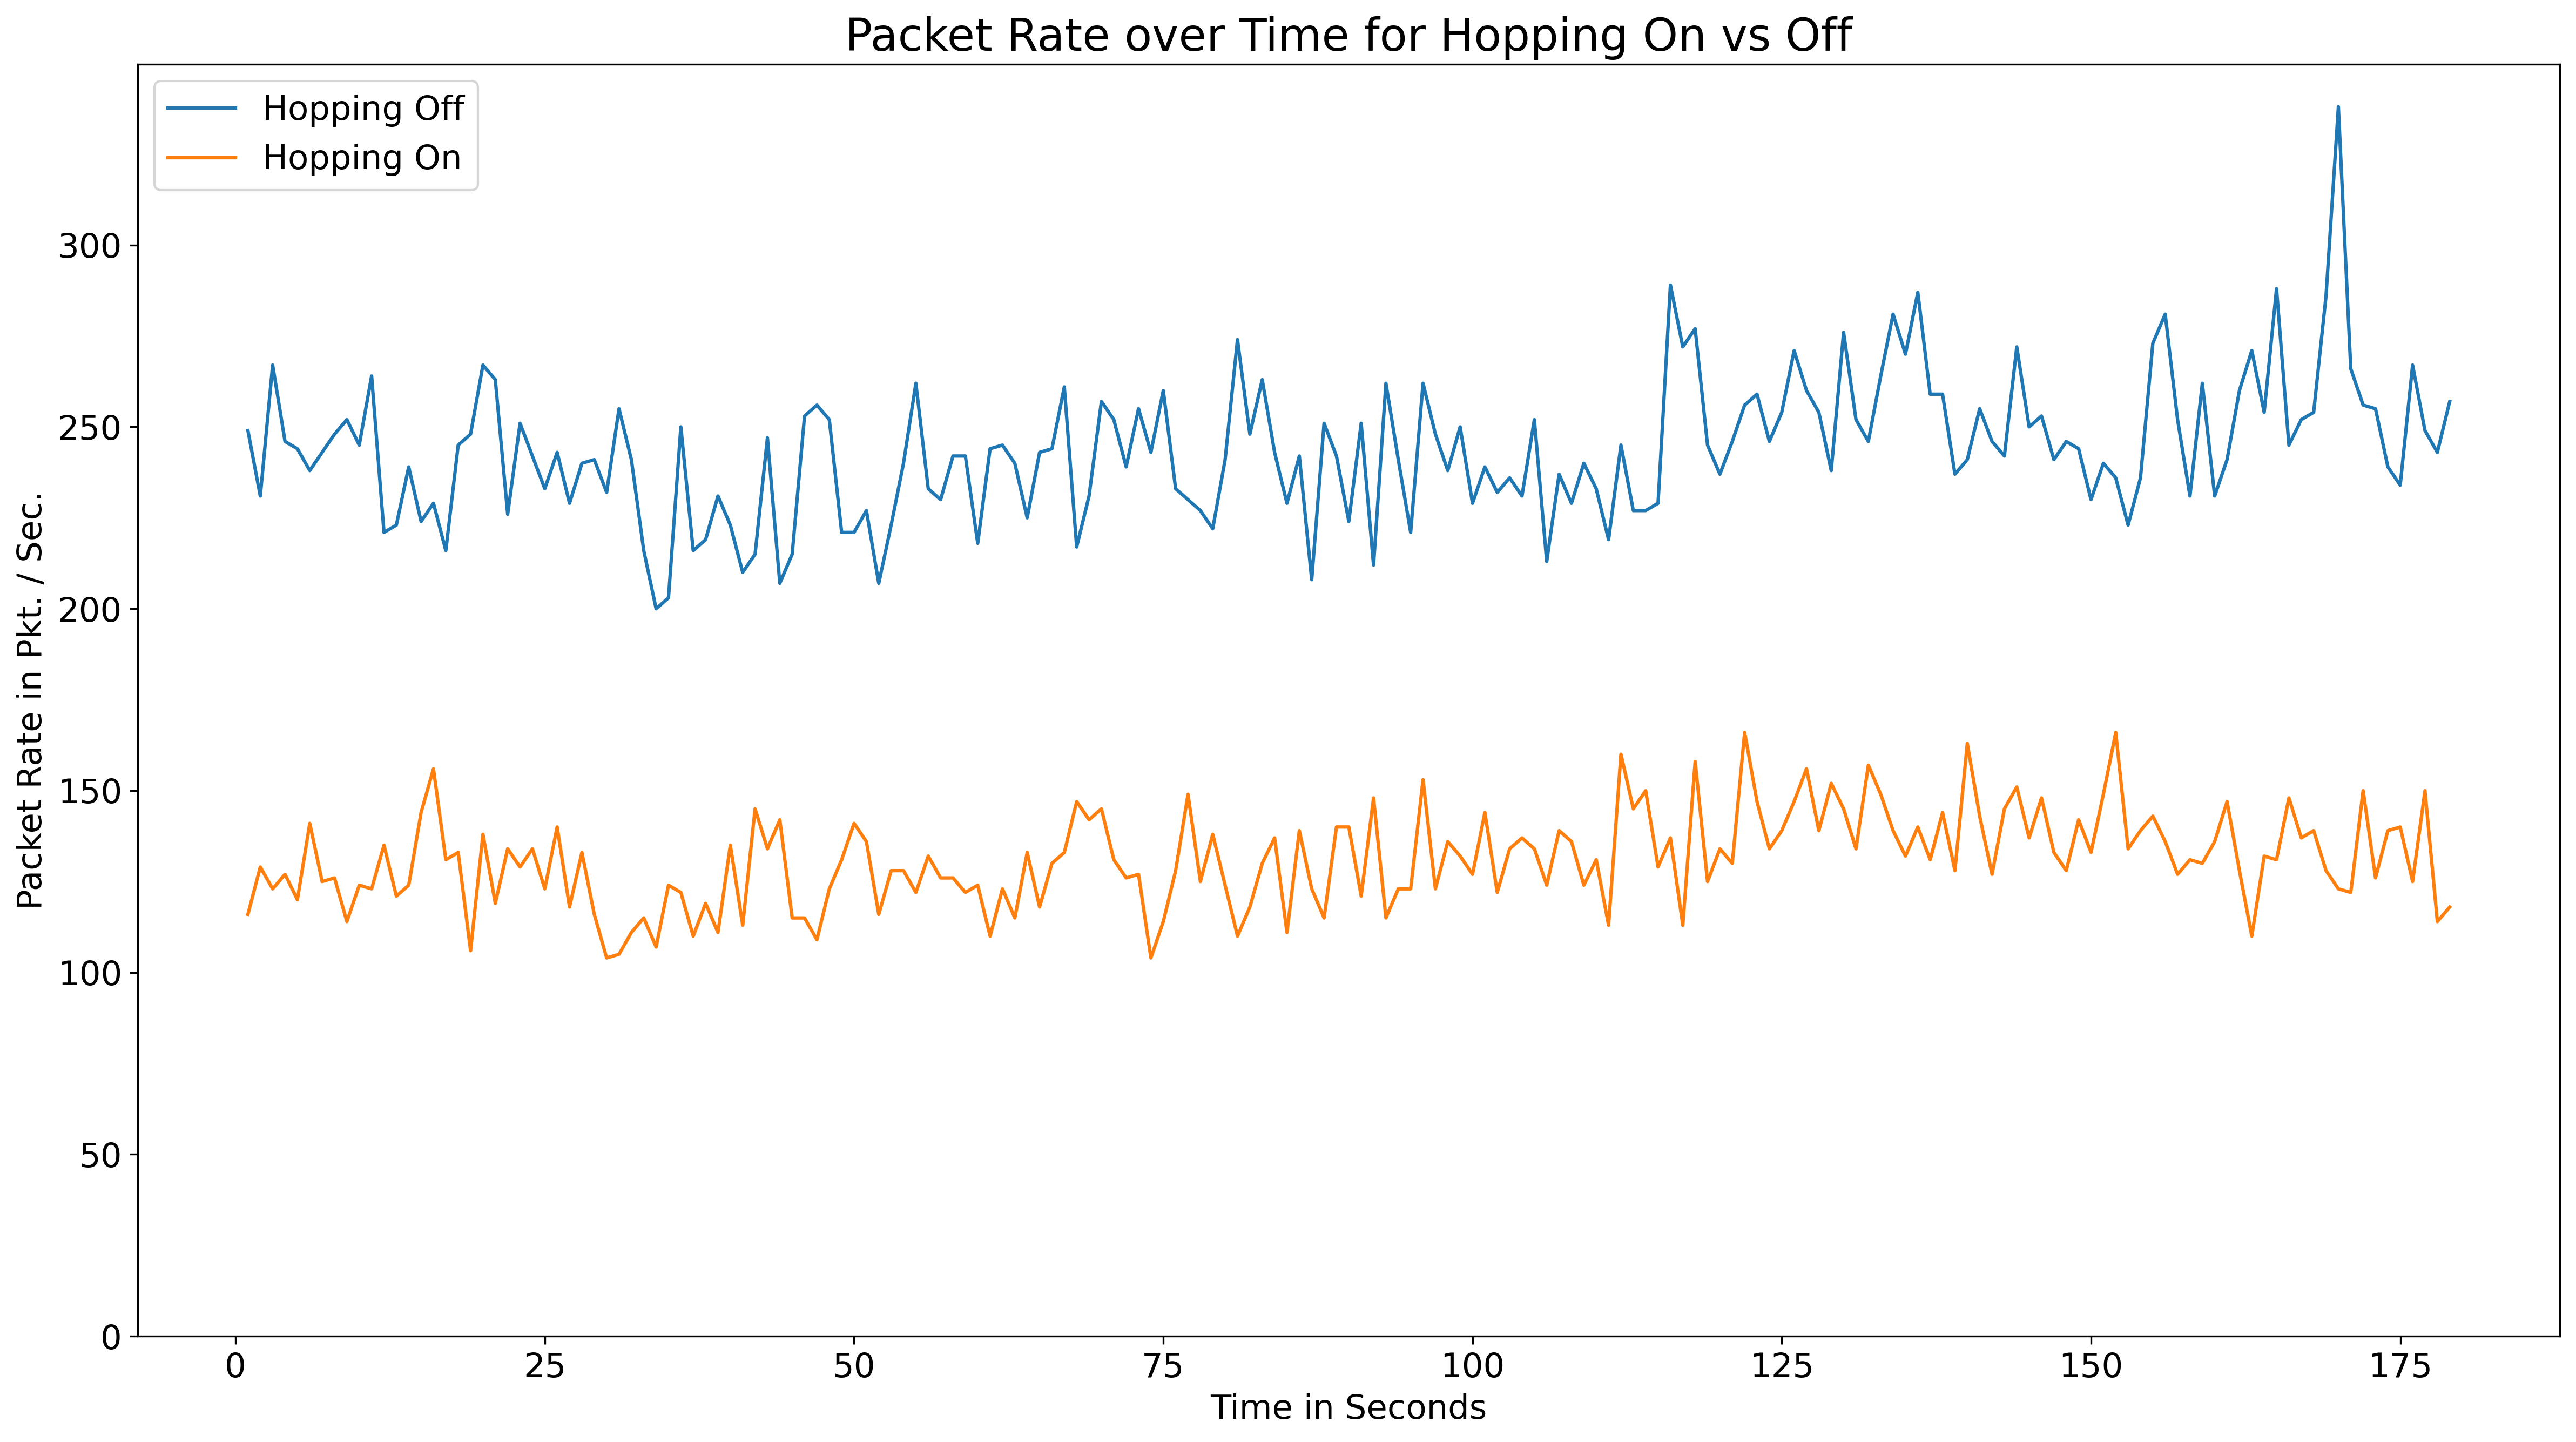

In [39]:
import matplotlib.pyplot as plt
plt.style.use('default')
plt.figure(dpi = 300, figsize=(16, 9))
plt.plot(ch_37_packet_rate['Time Delta'][1:-1], ch_37_packet_rate['Packet Count'][1:-1], label = 'Hopping Off')
plt.plot(hopping_packet_rate['Time Delta'][1:-1], hopping_packet_rate['Packet Count'][1:-1] , label = 'Hopping On')
plt.ylim(bottom = 0)
plt.legend(fontsize=15)
plt.ylabel('Packet Rate in Pkt. / Sec.', fontsize=15)
plt.xlabel('Time in Seconds', fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.title("Packet Rate over Time for Hopping On vs Off", fontsize=20)
plt.tight_layout()
plt.show()

In [10]:
import numpy as np

corr = np.corrcoef(ch_37_packet_rate['Packet Count'], hopping_packet_rate['Packet Count'])

In [11]:
corr

array([[1.        , 0.13441837],
       [0.13441837, 1.        ]])

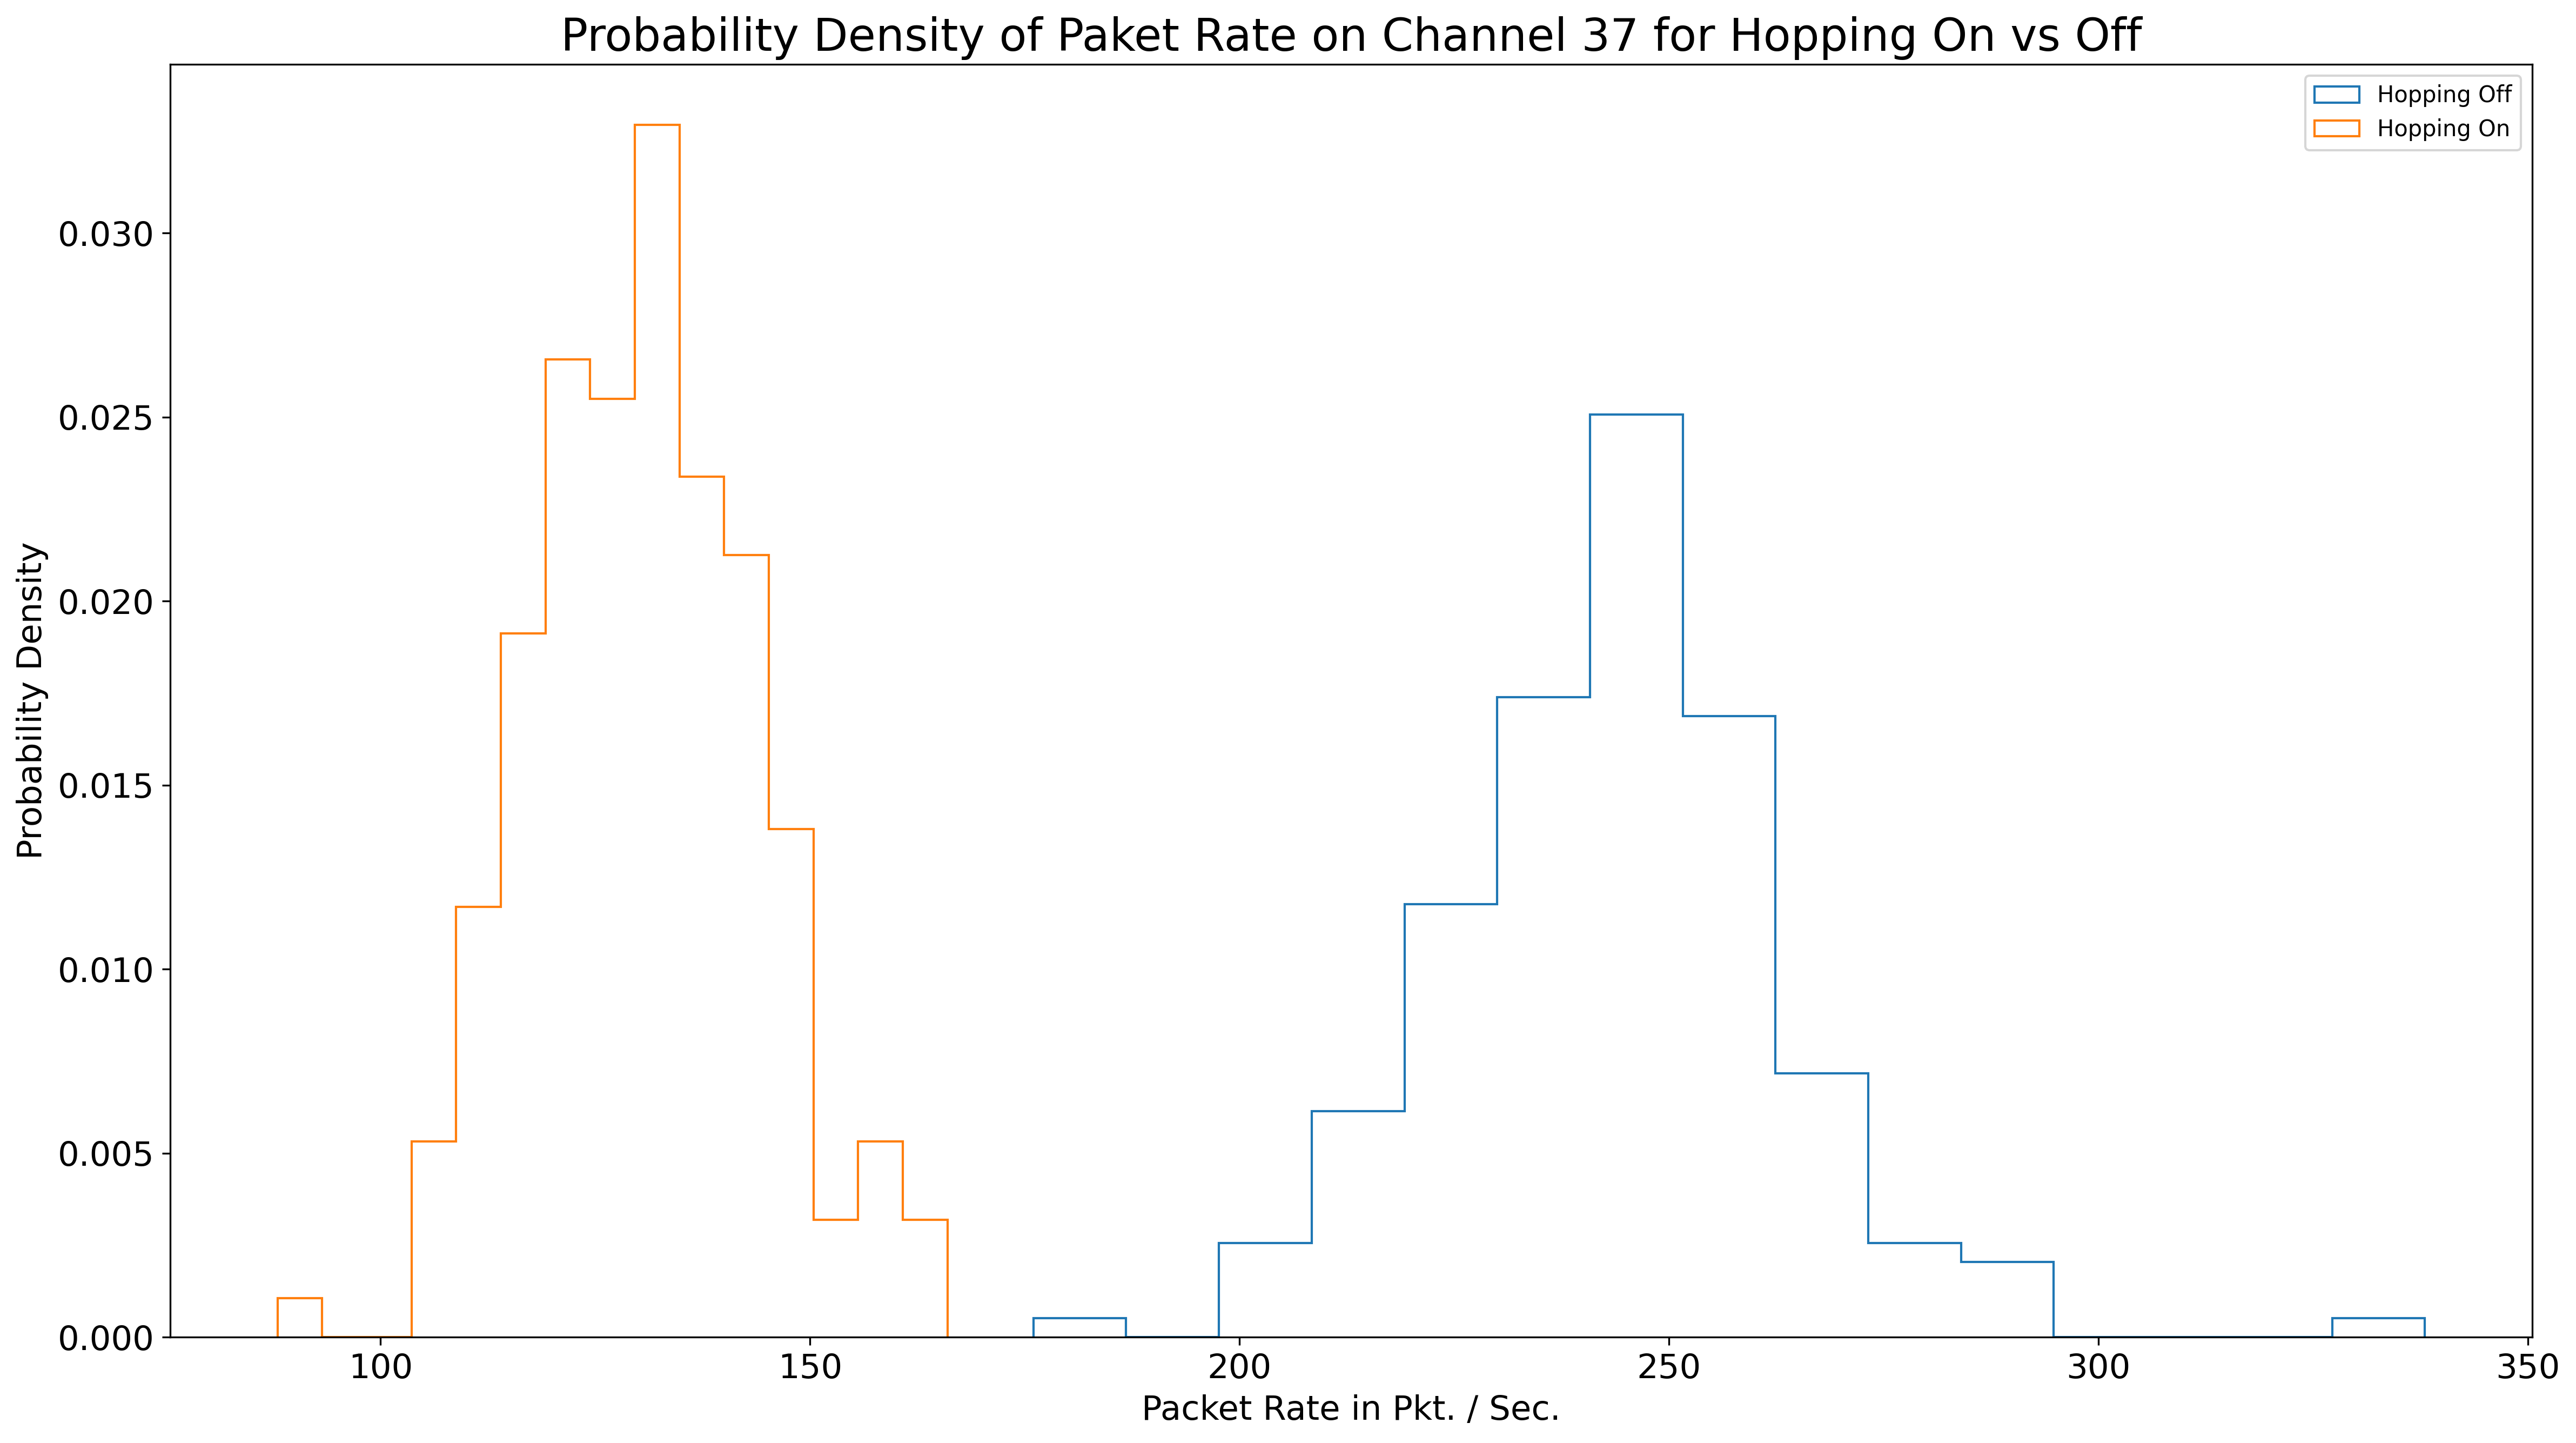

In [38]:
plt.figure(dpi = 300, figsize=(16, 9))
ch_37_packet_rate['Packet Count'].hist(bins=15, label='Hopping Off', density=True, histtype='step')
hopping_packet_rate['Packet Count'].hist(bins = 15, label = 'Hopping On', density=True, histtype='step')
plt.grid(False)
plt.legend(fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('Packet Rate in Pkt. / Sec.', fontsize=15)
plt.ylabel('Probability Density', fontsize=15)
plt.title("Probability Density of Paket Rate on Channel 37 for Hopping On vs Off", fontsize=20)
plt.style.use('default')
plt.tight_layout()
plt.legend()
plt.show()

In [13]:
mean_1, sigma_1, n_1 = ch_37_packet_rate['Packet Count'].mean(), ch_37_packet_rate['Packet Count'].std(), len(ch_37_packet_rate['Packet Count'])

mean_2, sigma_2, n_2 = hopping_packet_rate['Packet Count'].mean(), hopping_packet_rate['Packet Count'].std(), len(hopping_packet_rate['Packet Count'])

In [14]:
t_ind = (mean_1 - mean_2) / (sigma_1**2/n_1 + sigma_2**2/n_2)**0.5

In [15]:
t_ind

np.float64(63.7565990253884)

In [16]:
import scipy
t_val, p_val = scipy.stats.ttest_ind(ch_37_packet_rate['Packet Count'], hopping_packet_rate['Packet Count'])

In [17]:
t_val

np.float64(63.7565990253884)

In [18]:
p_val

np.float64(3.262615131821037e-198)

In [19]:
scipy.stats.normaltest(ch_37_packet_rate['Packet Count'])

NormaltestResult(statistic=np.float64(23.368740082113327), pvalue=np.float64(8.424469584335373e-06))

In [20]:
scipy.stats.normaltest(hopping_packet_rate['Packet Count'])

NormaltestResult(statistic=np.float64(0.44579378429948485), pvalue=np.float64(0.8001973516698723))

In [21]:
bin(123)

'0b1111011'

In [22]:
'0b011' + '0b001'

'0b0110b001'

In [23]:
hex()

TypeError: hex() takes exactly one argument (0 given)